# Phase 1 — Data Understanding (EDA)

**What is this notebook?** A guided tour of the loan applications data, focused on *business meaning* — not just statistics. Twelve figures, each answering one question a credit officer or risk manager would actually ask.

**Why do EDA at all?** Three concrete reasons:
1. **To set expectations** — if we know external credit scores dominate, a high model AUC later won't be mistaken for a leak (and a *too*-high one will be).
2. **To find landmines** — sentinel values, missing-data patterns, and imbalance all break models silently if not caught here.
3. **To feed the cost model** — Phase 4's per-applicant thresholds depend on contract types and loan terms; we measure their real distributions now.

**Who cares?** A credit officer (are the risk patterns sensible?), the Phase 4 cost model (what's the segment mix?), the Phase 5b fairness audit (do base rates differ by gender? — spoiler: yes), and any reviewer judging whether we understand our data.

**When?** After Phase 0 (splits frozen), before any feature engineering.

**Where?** All analysis uses the **dev set only** — the holdout stays sealed. Figures save to `reports/figures/`, tables to `reports/tables/`.

**How (DRY)?** Every plot is a function in `src/visualization/eda_plots.py`. This notebook calls them and explains them; `scripts/run_eda.py` calls the *same* functions to regenerate everything headlessly. One implementation, two consumers.

## 0. Wait — is this data preprocessed?

**Almost entirely no — and that is a decision, not an oversight.**

**What has been done:** exactly one fix, inside the loader — the `DAYS_EMPLOYED == 365243` pensioner placeholder is turned into NaN (you'll see why in section 6).

**What has NOT been done:** no imputation, no encoding, no outlier capping, no scaling.

**Why explore raw data?**
1. **Leakage safety.** Imputation medians, WOE bins, and encoders must be computed *inside* each CV fold (fit on 4 folds, apply to the 5th). Doing any of it now, on the whole dev set, would let every validation fold "see" statistics computed partly on itself — quiet leakage.
2. **EDA's job is to find the dirt.** If we cleaned first, we would never have discovered the sentinel, the 117-million income outlier, or that missingness itself predicts default. Cleaning before looking hides exactly what looking is for.

**When does preprocessing happen?** Phase 2, as fold-safe pipeline steps — and the rules for it come from this notebook's findings (see the data-quality audit below and the summary table at the end).

In [1]:
import sys
sys.path.insert(0, "..")

from src.data.load import load_dev_application
from src.visualization import eda_plots as ep

dev = load_dev_application()          # dev rows only, pensioner sentinel already fixed
print(f"Dev set: {dev.shape[0]:,} rows x {dev.shape[1]} columns")

Dev set: 246,008 rows x 122 columns


## 1. How imbalanced is the target?

**What:** count of repaid vs defaulted loans.

**Why it matters:** with only ~8% defaults, a model that approves *everyone* is "92% accurate" while being completely useless. So we never use accuracy. We use **AUC** (ranking quality) during modeling and **calibrated probabilities + costs** for decisions.

**How to read it:** the tiny orange bar *is* the entire problem we're paid to find.

8.07% positives -> accuracy is useless (reject-nothing scores 92%); PR-AUC baseline = 0.08.


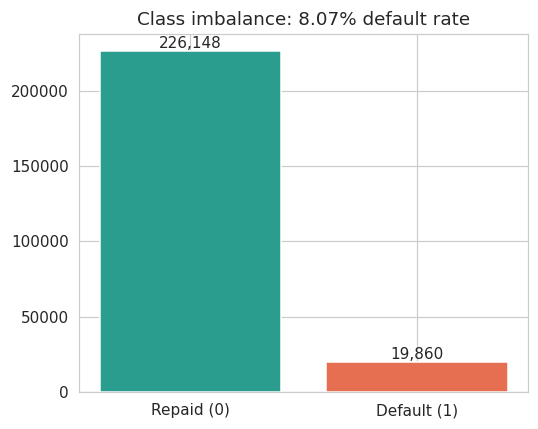

In [2]:
fig, takeaway = ep.plot_class_imbalance(dev)
print(takeaway)

## 2. Do the external credit scores work?

**What:** default rate by decile of `EXT_SOURCE_2` (an anonymized score from an external credit bureau).

**Why:** these three `EXT_SOURCE_*` columns will dominate every model we build. Knowing that *now* means later we won't misread "EXT_SOURCE tops the importance chart" as suspicious.

**How to read it:** left = worst-scored applicants (18.3% default), right = best (3.0%). A clean, monotonic 6× spread — this is what a genuinely predictive feature looks like.

EXT_SOURCE_2 bottom decile 18.3% vs top 3.0% default — external scores dominate; note upfront.


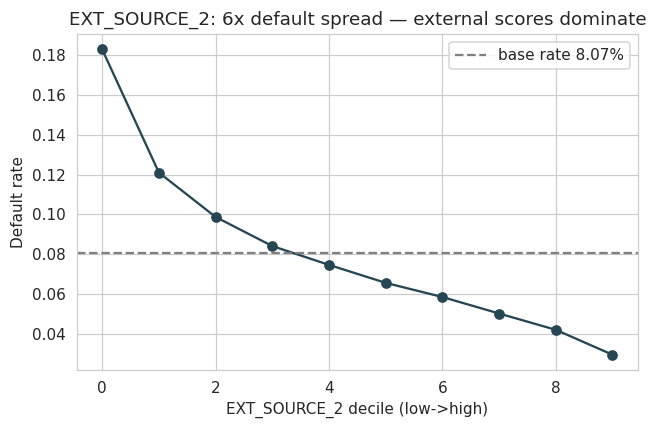

In [3]:
fig, takeaway = ep.plot_ext_source_deciles(dev)
print(takeaway)

## 3–4. Missing data — and why missingness is *information*

**What:** first, which columns are missing most; second, the default rate of people *with* vs *without* `EXT_SOURCE_1`.

**Why:** `EXT_SOURCE_1` is absent for 56% of applicants. Being unscored by a bureau usually means a thin credit history — and thin histories are riskier. Deleting or silently imputing would throw that signal away.

**How we'll use it (Phase 2):** keep the NaN *and* add an explicit `EXT_SOURCE_1_is_missing` flag. LightGBM handles NaNs natively; the flag makes the signal available to the logistic scorecard too.

EXT_SOURCE_1 56% missing; being unscored by a bureau is itself predictive -> explicit _is_missing flags.


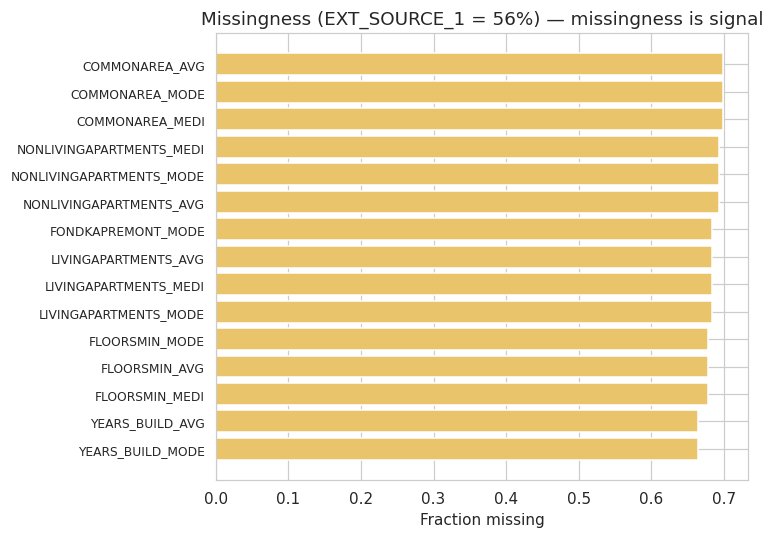

In [4]:
fig, takeaway = ep.plot_missingness(dev)
print(takeaway)

Applicants missing EXT_SOURCE_1 default at 8.5% vs 7.5% — missingness carries risk signal.


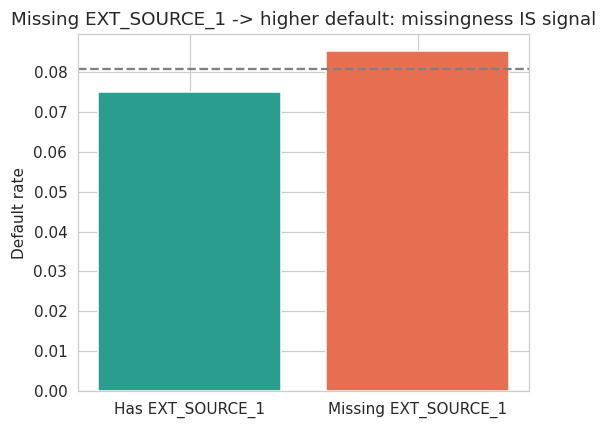

In [5]:
fig, takeaway = ep.plot_missingness_signal(dev)
print(takeaway)

## 5. Leverage — the credit-officer's first question

**What:** distribution of loan amount ÷ annual income, split by outcome.

**Why:** "how big is the loan relative to what they earn?" is the most natural underwriting question there is. Defaulters skew slightly higher.

**Honest caveat:** the separation is modest — this feature helps in combination, not alone.

Credit/income leverage: defaulters skew slightly higher — a credit-officer feature.


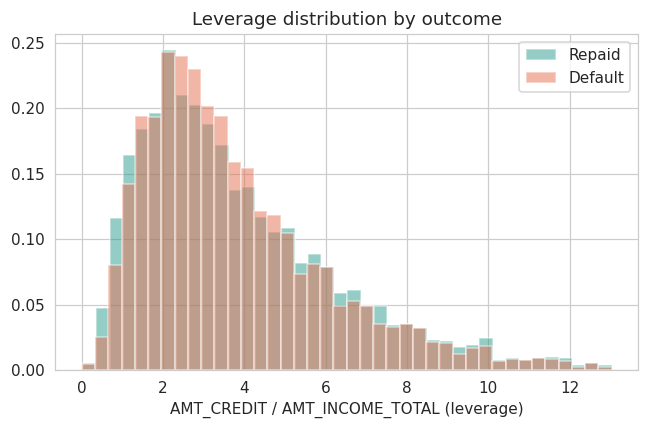

In [6]:
fig, takeaway = ep.plot_leverage_distribution(dev)
print(takeaway)

## 6. Employment length — and the pensioner landmine

**What:** default rate by years employed.

**The landmine:** 17.9% of rows have `DAYS_EMPLOYED = 365243` — that's *1,000 years*. It's Home Credit's placeholder code for pensioners. Left unfixed, a model learns nonsense ("people employed 1,000 years are safe").

**How we fixed it:** our loader (`load_dev_application`) converts the sentinel to NaN; Phase 2 adds an `is_pensioner` flag so the information ("retired") survives while the fake number dies.

**How to read the plot:** shorter employment → higher default, smoothly. Sensible.

Shorter employment -> higher default; the 365243 pensioner sentinel (17.9%) fixed to NaN+flag.


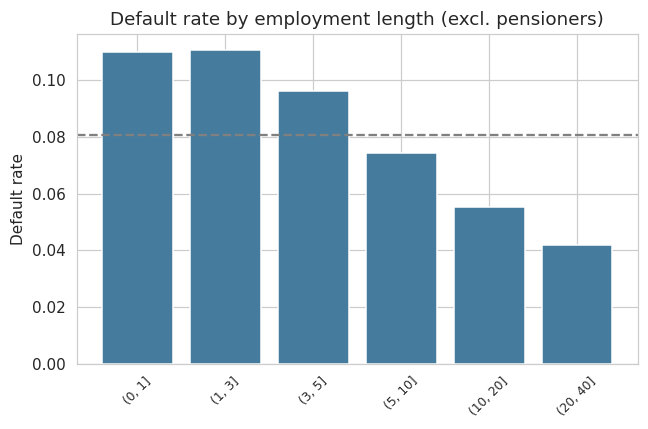

In [7]:
fig, takeaway = ep.plot_employment_length(dev)
print(takeaway)

## 7. Age

**What:** default rate by age band.

**Why:** classic credit-risk pattern check — younger borrowers default more (less stable income, thinner savings). Our data agrees: 20–30s sit well above the base rate, 60+ well below.

**A quiet fairness note:** age patterns are legally sensitive in some jurisdictions. We keep age (it's standard in credit scoring) but the Phase 5b audit machinery is built exactly for questions like this.

Younger applicants (20-30) default well above base rate; risk falls with age.


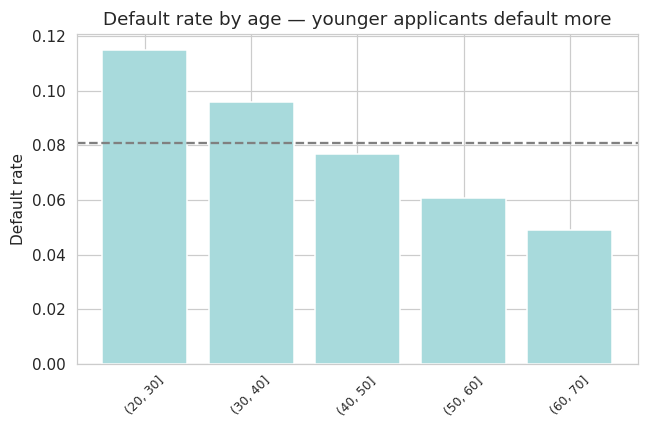

In [8]:
fig, takeaway = ep.plot_age(dev)
print(takeaway)

## 8. Segment scan I — contract type (feeds the cost model)

**What:** default rate and volume for cash loans vs revolving credit.

**Why this matters for Phase 4:** our per-applicant threshold t*(x) uses different LGD and EAD constants for cash vs revolving. This plot tells us revolving is only **9.5% of the book** — so the cash/revolving distinction moves *few* applicants, and most threshold variation will come from **loan term** instead. Knowing this *before* computing the cost gap means we won't over-promise what the contract split delivers.

Cash defaults 8.3% vs revolving 5.5%; revolving only 9.5% of applications -> LGD/EAD split moves fewer applicants.


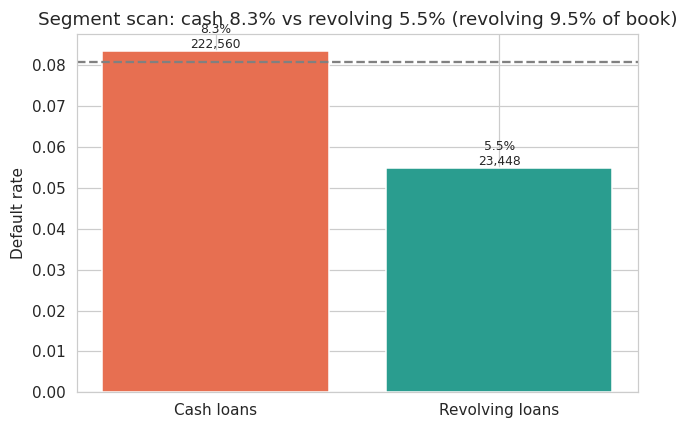

In [9]:
fig, takeaway = ep.plot_segment_scan_contract(dev)
print(takeaway)

## 9. Gender base rates — pre-registering the fairness finding

**What:** raw default rate for female vs male applicants.

**Why show this now?** Phase 5b will audit our deployed decisions for gender fairness. Because the *base rates genuinely differ* (F 7.0%, M 10.1%), some fairness metrics may flag even with gender excluded from the model. We are writing that expectation down **before** building anything — so the later result is a *pre-registered finding we report*, not a surprise we're tempted to hide.

**What we do about it (decided in the spec):** `CODE_GENDER` is dropped from modeling features in Phase 2 and kept only in a separate audit table. The audit *measures and discloses*; it does not silently remediate (per-group thresholds in credit would themselves be disparate treatment).

Base default rates differ by gender (F 7.0%, M 10.1%) -> disparate-impact flag is a live possibility (Phase 5b).


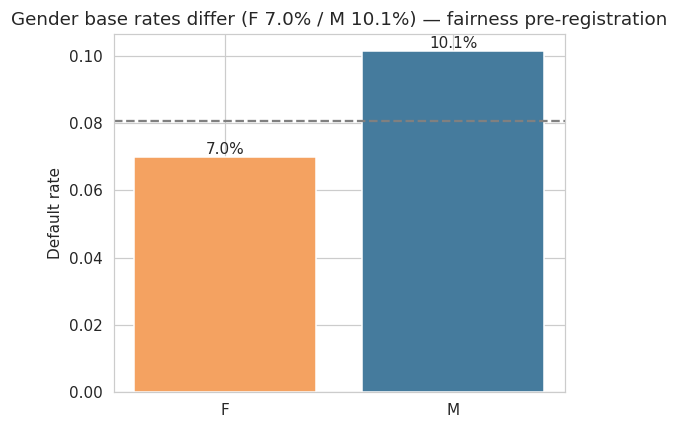

In [10]:
fig, takeaway = ep.plot_gender_base_rates(dev)
print(takeaway)

## 10. Correlations — any single feature too good?

**What:** Spearman correlation between key features and the target.

**Why:** a feature correlating suspiciously strongly with TARGET (say |ρ| > 0.5) would smell like leakage. Here the strongest are the EXT_SOURCE scores at ρ ≈ −0.16 to −0.19 — strong enough to matter, nowhere near leak territory.

**Also visible:** `AMT_CREDIT` and `AMT_ANNUITY` correlate 0.77 with each other (bigger loans → bigger payments). Phase 2's correlation pruning (cutoff |ρ| > 0.98) keeps both; they're related but not redundant.

EXT_SOURCE_* most correlated with TARGET (negative); no single raw feature is dominant enough to leak.


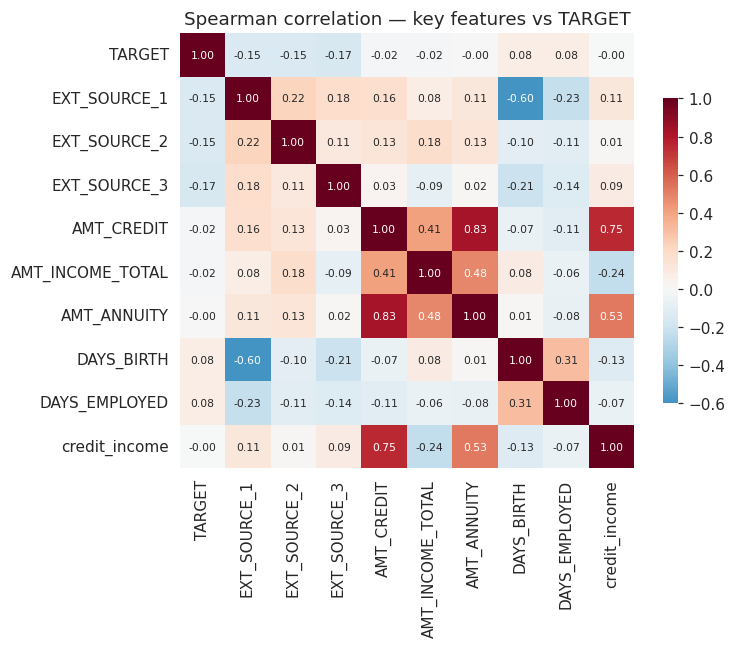

In [11]:
fig, takeaway = ep.plot_correlation(dev)
print(takeaway)

## 11. Leverage deciles — an honest negative result

**What:** default rate by credit/income decile.

**Why include a weak result?** Because it's true. The spread is only 6.8%→9.2% — far flatter than EXT_SOURCE's 3%→18%. Raw leverage is a weaker solo predictor than intuition suggests (likely because approved loans were already screened on it — a preview of the *reject inference* limitation we document in Phase 7).

**How this changes Phase 2:** leverage earns its seat through *interactions* (e.g., leverage × income level), not alone.

Leverage deciles surprisingly flat (6.8%-9.2%) — raw leverage weaker than expected; interactions needed.


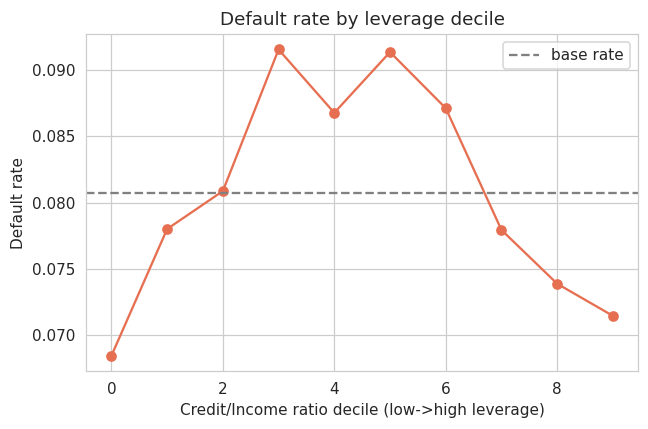

In [12]:
fig, takeaway = ep.plot_leverage_deciles(dev)
print(takeaway)

## 12. Segment scan II — loan term (the real driver of t*(x))

**What:** default rate by implied loan term. Term isn't given directly; we derive it: `term ≈ AMT_CREDIT / (12 × AMT_ANNUITY)` — "how many monthly payments would repay the principal", capped to [0.5, 7] years.

**Why term matters more than anything for Phase 4:** in the threshold formula t*(x) = m(x)/(m(x)+L(x)), the margin m(x) for cash loans is proportional to term. Longer loan → more profit at stake when we wrongly reject → the system tolerates more risk. This plot shows terms cluster at 1–3 years, so that's where our thresholds will live.

**A subtle finding worth writing down:** default rate is **non-monotonic** in term — it *peaks* at 1–1.5y (10.3%) and *falls* to 4.6% at 3–5y. Longer terms go to better-vetted borrowers. So term drives the *threshold* up and the *risk* down at the same time — a nice concrete example of why instance-dependent decisioning isn't just "stricter on risky people."

The bucket table (default rate, avg credit, count) is saved to `reports/tables/segment_scan_term.csv` for the methodology doc.

Terms cluster 1-3y; default rate NON-monotonic in term (peak 10.3% at 1-1.5y). Table saved to reports/tables/.


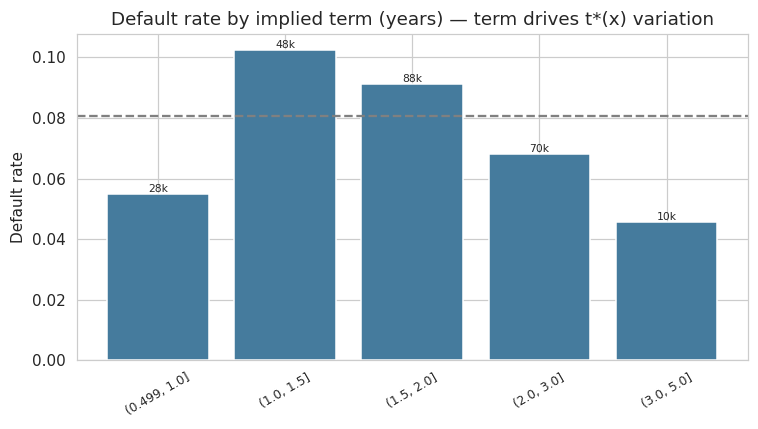

In [13]:
fig, takeaway = ep.plot_term_buckets(dev)
print(takeaway)

## 13. Data-quality audit — the systematic "what's broken" pass

**What:** ten scripted checks for the classic ways tabular data lies: duplicates, placeholder codes, impossible values, dead columns, absurd outliers.

**Why scripted instead of eyeballed?** Because each finding becomes a preprocessing *rule* in Phase 2, and rules should come from re-runnable code (`src/data/quality.py`), not from memory of what someone once noticed.

**How to read the table:** `severity` says how much it matters; `action_for_phase2` is the exact preprocessing decision it triggers. Highlights:
- **`AMT_INCOME_TOTAL` max is 117,000,000** — 248× the 99th percentile. One applicant "earns" more than some small countries. LightGBM is rank-based and shrugs; the logistic scorecard needs a log transform.
- **10 near-constant columns** (e.g. `FLAG_MOBIL` is one value for >99.9% of rows) — pure dead weight, dropped in Phase 2.
- **`AMT_ANNUITY` missing for 10 rows** — tiny, but it feeds the t*(x) term formula, so the cost model needs an explicit rule for it, not a silent crash.

In [14]:
from src.data.quality import data_quality_audit

audit = data_quality_audit(dev)      # also saved to reports/tables/
audit

,check,result,severity,action_for_phase2
0,Duplicate SK_ID_CURR,0 duplicates,ok,none needed
1,CODE_GENDER == 'XNA',2 rows,minor,exclude from gender fairness audit groups (kee...
2,AMT_INCOME_TOTAL max vs p99,"max=117,000,000 vs p99=472,500 (248x)",major,log-transform for logistic; LightGBM splits ar...
3,AMT_ANNUITY missing,10 rows,major (cost model input),impute with fold-median for term calc; flag; c...
4,AMT_GOODS_PRICE missing,221 rows,minor,ratio -> NaN + _is_missing flag (LightGBM hand...
5,DAYS_EMPLOYED sentinel remaining,0 rows (0 = loader fixed it),ok,add is_pensioner flag from NAME_INCOME_TYPE=='...
6,Constant columns,none,minor,drop
7,Near-constant columns (>99.9% one value),"10: ['FLAG_MOBIL', 'FLAG_DOCUMENT_2', 'FLAG_DO...",minor,"drop (no signal, wastes selection budget)"
8,Non-positive AMT_CREDIT,0 rows,ok,none needed
9,CNT_FAM_MEMBERS max,20,minor,cap at p99.9 for logistic; leave for LightGBM


## 14. Categorical risk patterns — education & income type

**What:** default rate by education level and by income type (groups under 200 applicants hidden — their rates are noise).

**Why:** these are core underwriting variables, and a sanity check in both directions: the *pattern* should make credit sense (it does — lower-secondary education defaults ~2× higher education; 'Working' is riskier than pensioners or state servants), and the *magnitudes* preview real predictive power for Phase 2.

**The fairness angle (writing it down now):** occupation-and-income variables like these are exactly the features the spec predicts will partially encode gender. They stay in the model — they are legitimate underwriting signals — but they are why the Phase 5b proxy check *will* fire, and why we pre-registered "measure and disclose" rather than "fix".

Lower-secondary education ~2x default of higher education; 'Working' income type riskier than pensioners/state servants — strong, sensible categoricals (also gender-correlated: proxy-audit relevance).


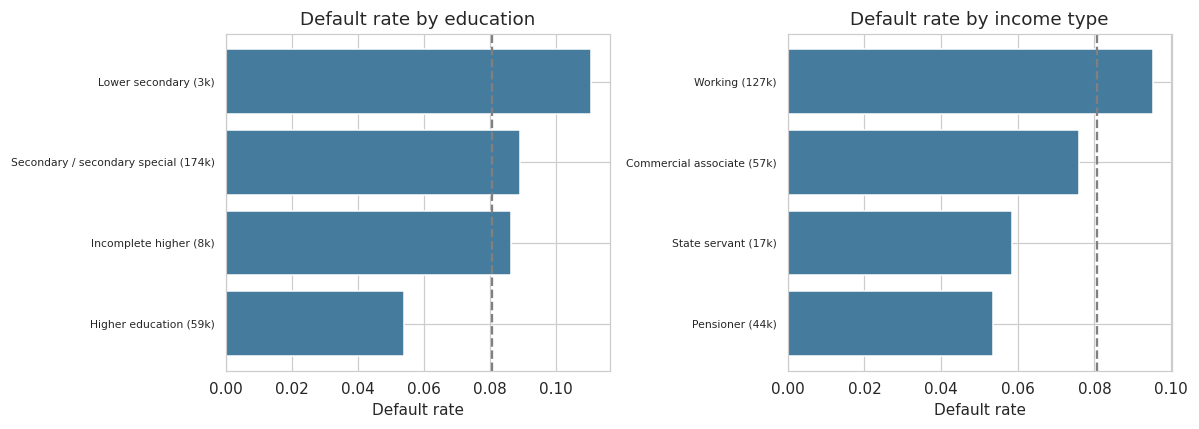

In [15]:
fig, takeaway = ep.plot_categorical_risk(dev)
print(takeaway)

## 15. Opening auxiliary table #1 — bureau (credit history elsewhere)

**What:** `bureau.csv` has 1.7M rows — one per prior loan each applicant holds at *other* institutions. Here: default rate by *how many* prior loans an applicant has.

**Why this table matters:** joining and aggregating it is **differentiator #1** of the whole project. This first look tells us the join is worth it before we invest Phase 2 effort.

**How to read it — the interesting inversion:** applicants with **zero** bureau records are the *riskiest* group (10.1% default), not the safest. No history ≠ clean history; it means *unknown* — the thin-file problem every real lender faces. Applicants with some history sit at 7.4–8.2% regardless of count.

**What Phase 2 takes from this:** a `has_bureau_history` flag is mandatory, and count-features alone are weak — the value will come from *quality* aggregates (overdue amounts, debt ratios, active-loan counts).

No bureau history -> 10.1% default (riskiest); some history ~7.4-8.2%. Thin-file risk confirms 'missingness is signal' at the table level.


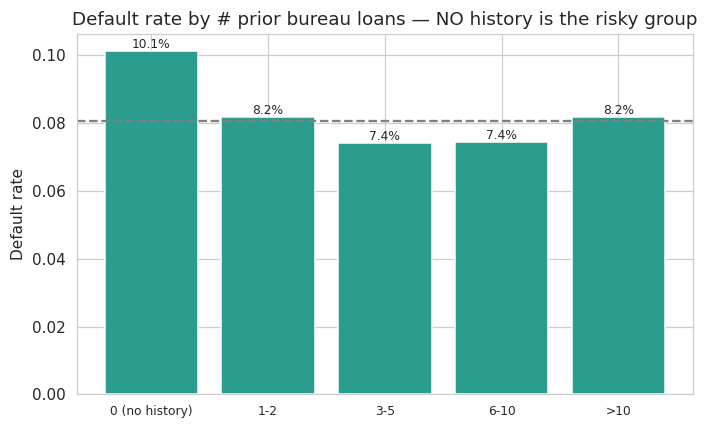

In [16]:
fig, takeaway = ep.plot_bureau_history_signal(dev)
print(takeaway)

## 16. Opening auxiliary table #2 — previous applications at Home Credit

**What:** `previous_application.csv` (1.67M rows) records every *earlier* application these same people made to Home Credit. Here: default rate by the *share of those applications that were refused*.

**Why:** the spec flags "prior rejections are highly predictive" — this tests that claim before we build features on it.

**How to read it — the strongest signal outside EXT_SOURCE:** a clean monotone staircase from 7.1% (never refused) to **15.9%** (mostly refused) — a 2.2× risk multiplier. Someone other underwriters kept rejecting is telling us something.

**One subtlety worth noticing:** applicants with *no* prior Home Credit history default at just 6.0% — the safest group. Opposite direction from the bureau table's no-history group! Plausible reading: "new to Home Credit" often means an established borrower trying a new lender, while "invisible to all bureaus" means genuinely thin credit. Two kinds of 'no history' with opposite meanings — exactly the nuance aggregation features must preserve (separate flags, not one merged 'has_history').

Prior refusal share is a clean monotone signal: 7.1% -> 15.9% default. Prior rejections are highly predictive — top Phase 2 aggregation.


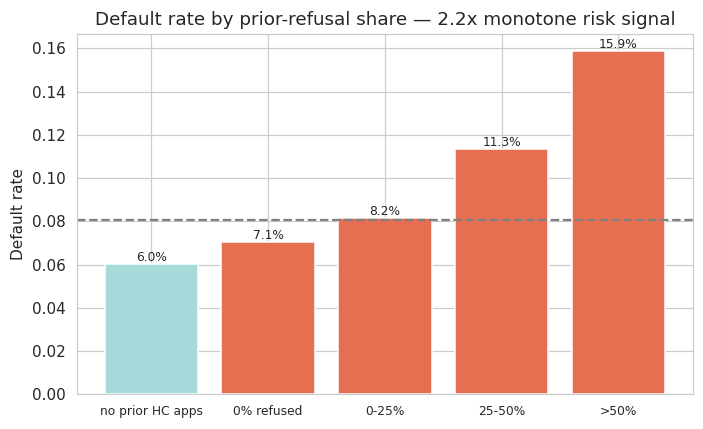

In [17]:
fig, takeaway = ep.plot_prev_refusal_signal(dev)
print(takeaway)

## 17. Closing the last gaps — four table-based checks

Before declaring EDA done, we reviewed what *downstream phases need* and found four unexplored spots. None needs a figure (we're at the spec's 15-plot cap); tables do the job. All code in `src/data/supplementary.py`, outputs in `reports/tables/`.

### 17a. bureau_balance — the 27-million-row table we hadn't opened

**What:** monthly payment-status history for bureau loans. STATUS codes: `C` = closed, `0` = paid on time, `X` = unknown, `1`–`5` = escalating days-past-due (5 = 120+ days or write-off).

**The two facts that shape Phase 2:**
- **Delinquency is rare in the monthly grid** — statuses 1–5 together are only ~1.3% of rows. So "ever had DPD≥1" style flags will be sparse but likely potent (rare + bad is the classic high-IV pattern).
- **Coverage is only 35.7%** — two-thirds of our applicants' bureau loans have *no* monthly history at all. Any bureau_balance feature must come with a coverage flag, or its NaNs will silently mean "no data" and "no delinquency" at the same time — the exact two-kinds-of-nothing trap we found in section 16.

In [18]:
from src.data.load import load_bureau, load_bureau_balance
from src.data.supplementary import (bureau_balance_overview, bureau_side_fields,
                                    dti_default_table, downpayment_default_table)

bureau = load_bureau()
bureau_dev = bureau[bureau["SK_ID_CURR"].isin(set(dev["SK_ID_CURR"]))]
bb = load_bureau_balance()

bureau_balance_overview(bureau_dev, bb)

,share
STATUS,
C,0.4999
0,0.2747
X,0.2128
1,0.0089
5,0.0023
2,0.0009
3,0.0003
4,0.0002
— dev bureau loans with any balance history —,0.3568


### 17b. bureau side-fields — three quick join-planning facts

**Why check fields that might be boring?** Because *confirmed-boring is a finding*: it licenses Phase 2 to ignore things without guilt.

- **37% of bureau loans are Active** → "active-loan" aggregates (current debt, current utilization) have plenty of mass. Worth building.
- **99.9% are currency 1** → `CREDIT_CURRENCY` is dead; drop it, saving a useless categorical.
- **Median record is 2.7 years old** (p90 = 6.7y) → history is recent enough that recency-weighted features are optional, not mandatory.

In [19]:
bureau_side_fields(bureau_dev)

,value
share_active,0.3701
share_closed,0.6260
share_currency_1,0.9991
recency_median_years,2.6986
recency_p90_years,6.7096


### 17c. DTI (payment burden) — an honest negative result

**What:** default rate by `AMT_ANNUITY / AMT_INCOME_TOTAL` — "what share of income goes to this loan's payments." A listed Phase 2 domain ratio we had never actually tested.

**The surprise:** it's nearly **flat** (7.2% → 8.8%, and it *bends back down* above 50% DTI). The single most intuitive affordability measure barely separates outcomes here.

**Why (most likely):** the same reject-inference story as leverage — these are *approved* loans, already screened on affordability. The unaffordable applications never made it into our data. High-DTI approvals were presumably approved *because* something else looked strong.

**Consequence:** keep DTI (cheap, interpretable, expected by any credit reviewer) but expect little solo lift — its value, like leverage, is in interactions.

In [20]:
dti_default_table(dev)

,default_rate,n
"(0.0, 0.1]",0.0715,45829
"(0.1, 0.2]",0.0802,116103
"(0.2, 0.3]",0.0881,58979
"(0.3, 0.5]",0.0831,23059
"(0.5, 10.0]",0.0759,2028


### 17d. Down-payment ratio — the best raw application-table find so far

**What:** `AMT_CREDIT / AMT_GOODS_PRICE` on cash loans — how the loan compares to the price of the thing bought. Ratio > 1 means fees/insurance were financed *into* the loan.

**Two findings, both strong:**
1. **71.4% of cash loans exceed the goods price.** Financing the fees is the norm, not the exception — worth knowing before interpreting the ratio.
2. **Risk doubles across the ratio:** 6.5% default at 1.0–1.15 → **12.8%** above 1.3. Borrowing well past the item's value is the strongest raw-application-table signal we've found outside EXT_SOURCE.

**Consequence for Phase 2:** this ratio is a priority feature; also worth a `financed_fees_share` variant ((credit − goods)/goods).

In [21]:
tbl = downpayment_default_table(dev)
print(f"share of cash loans with credit > goods price: {tbl.attrs['share_above_1']:.1%}")
tbl

share of cash loans with credit > goods price: 71.4%


,default_rate,n
"(0.8, 1.0]",0.0722,63631
"(1.0, 1.15]",0.0650,65534
"(1.15, 1.3]",0.0960,69833
"(1.3, 5.0]",0.1280,23562


---
# Part 2 — Deep-dive additions (post-review)

A second review pass against a senior-DS EDA checklist lifted the figure cap and surfaced five more analyses worth doing. Same rules as Part 1: every figure answers a business question; all logic lives in `src/`.

## 19. Dataset overview — the numbers a reviewer asks for first

**What:** shape, memory, dtypes, duplicates, missingness tiers in one table.

**Why bother with "boring" stats?** Because they're the sanity floor: zero duplicate rows means no accidental double-counting of applicants; the numeric/categorical split tells us the encoding workload; and the missingness tiers (**41 columns >50% missing, none >80%**) tell us a third of the table is housing-block statistics that mostly aren't there — those 41 columns live or die by the null-importance selection in Phase 2, not by hand-wringing.

In [22]:
from src.data.supplementary import (dataset_overview, univariate_auc_scan,
                                    skewness_table)

dataset_overview(dev)

,value
rows,246008.0000
columns,122.0000
memory_mb,273.4000
duplicate_rows,0.0000
numeric_features,106.0000
categorical_features,16.0000
cols_with_any_missing,68.0000
cols_missing_gt_50pct,41.0000
cols_missing_gt_80pct,0.0000
default_rate,0.0807


## 20. Raw distributions — what shape is the data actually in?

**What:** histograms of the 8 core numerics (income shown on log scale).

**Why:** Part 1 jumped straight to decile views, which *hide* shape. Shape decides transformations: the logistic scorecard assumes roughly well-behaved inputs; LightGBM does not care (it only uses ranks).

**How to read it:**
- `AMT_INCOME_TOTAL` has **skewness 375** — one applicant reports 117M income. Log-transform for the scorecard; irrelevant for LightGBM.
- `AMT_CREDIT`/`AMT_ANNUITY` are mildly right-skewed (1.2–1.6) — acceptable as-is.
- `DAYS_EMPLOYED` shows the post-sentinel-fix shape: a clean left tail with the pensioner mass now NaN instead of a fake spike at 1,000 years.
- `EXT_SOURCE_*` are already smooth 0–1 scores — someone normalized them for us.

AMT_INCOME_TOTAL skew=375 (shown logged) -> log for logistic; credit/annuity mildly right-skewed (1.2-1.6, fine); EXT_SOURCE_* already smooth 0-1 scores.


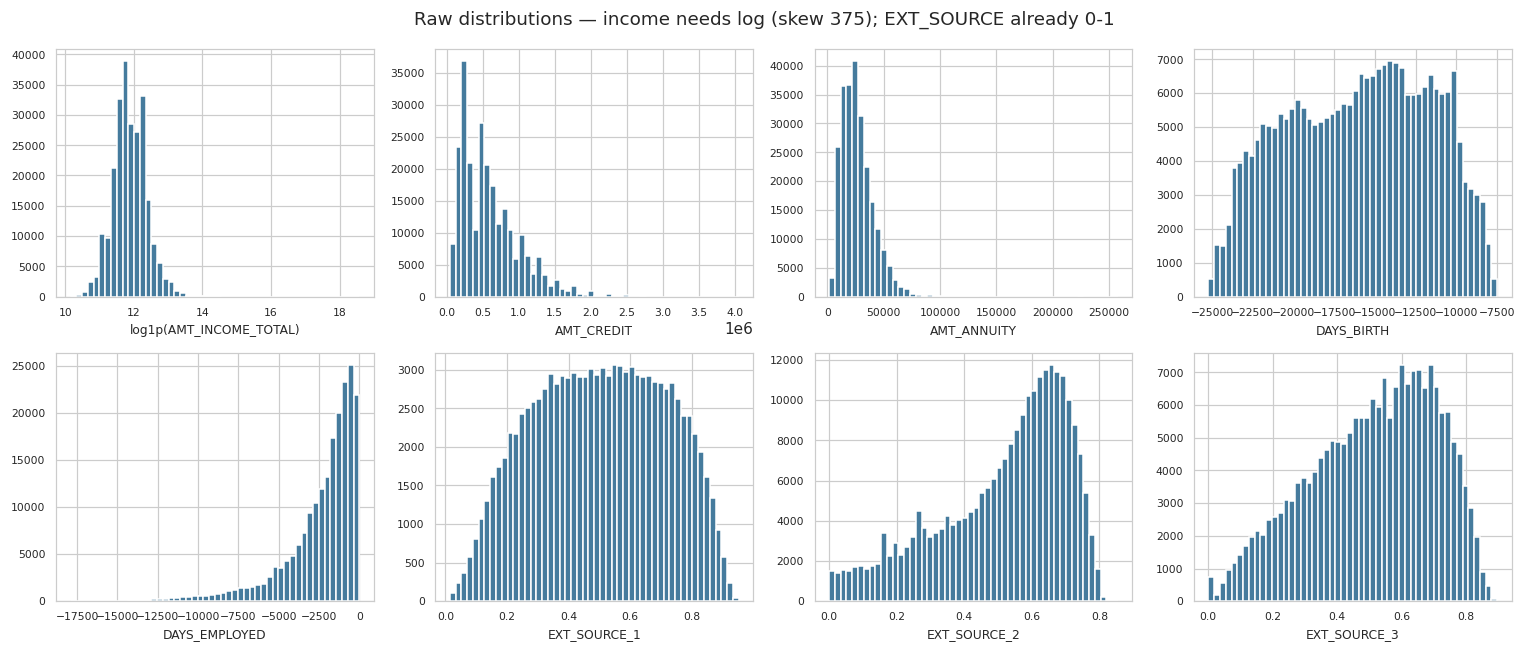

In [23]:
fig, takeaway = ep.plot_numeric_distributions(dev)
print(takeaway)

In [24]:
skewness_table(dev)

,skewness,action
feature,,
AMT_INCOME_TOTAL,375.1,log-transform for logistic
AMT_CREDIT,1.2,none needed
AMT_ANNUITY,1.6,none needed
AMT_GOODS_PRICE,1.3,none needed
DAYS_BIRTH,-0.1,none needed
DAYS_EMPLOYED,-2.0,none needed
EXT_SOURCE_1,-0.1,none needed
EXT_SOURCE_2,-0.8,none needed
EXT_SOURCE_3,-0.4,none needed


## 21. All three EXT_SOURCE scores — do they tell the same story?

**What:** Part 1 showed only `EXT_SOURCE_2`'s decile curve. Here are all three, overlaid.

**Why:** if the three external scores disagreed, we'd have a puzzle (which bureau is right?). They don't — all three are monotone with similar spreads, differing mainly in *coverage* (from ~44% to ~100% of applicants).

**Consequence for Phase 2:** three agreeing noisy measurements of the same underlying creditworthiness beg to be averaged — `ext_source_mean` (over whichever are present) is an obvious high-value engineered feature, plus a count-present feature (which doubles as a thin-file indicator).

All three EXT_SOURCEs are monotone with similar spreads — they corroborate each other; their MEAN is an obvious Phase 2 feature.


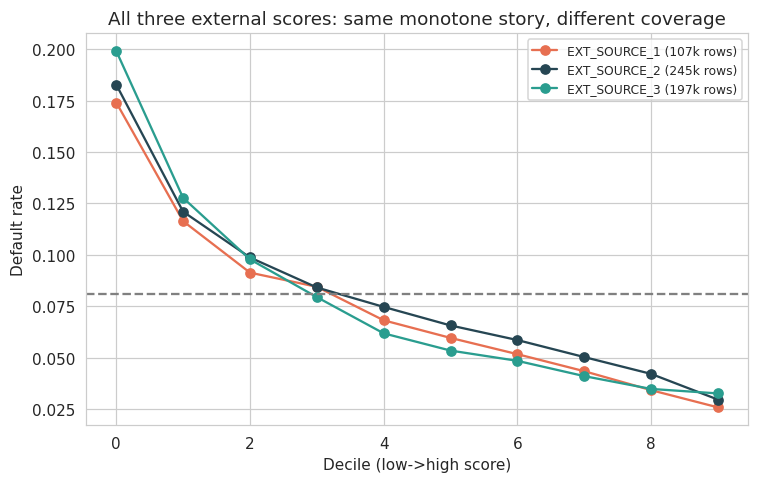

In [25]:
fig, takeaway = ep.plot_ext_source_all_deciles(dev)
print(takeaway)

## 22. Money deciles — income and credit amount alone

**What:** default rate by income decile and by credit-amount decile.

**Why:** completes the "raw money is weak" picture from Part 1 (flat leverage, flat DTI). Both curves are shallow — a 2–3 percentage-point spread, versus EXT_SOURCE's 15-point spread.

**The pattern worth naming:** *every* affordability-style variable (income, credit size, leverage, DTI) is individually weak in this data, and the most plausible common cause is that the approval process already filtered on them. That's the reject-inference footprint appearing for the fourth time — which is why it gets its own half-page in the methodology doc.

Income and credit-amount deciles are shallow (~2-3pp spread) — raw money variables are weak solo predictors, consistent with the flat leverage/DTI findings (reject-inference footprint).


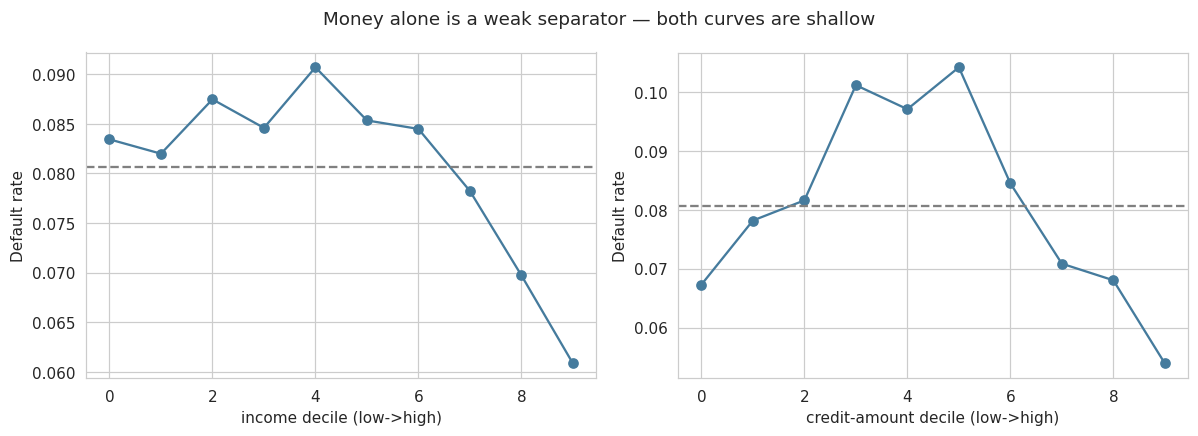

In [26]:
fig, takeaway = ep.plot_amount_deciles(dev)
print(takeaway)

## 23. The heavy categoricals — occupation, family status, organization

**What:** the three categoricals Part 1 skipped, including the awkward ones.

**How to read the three panels:**
- **Occupation (18 levels, 31% missing):** spans 4.6% (accountants) to 18.1% (low-skill laborers) — a 4× range, as strong as any raw feature we have. And the *missing* group sits **below** base rate — occupation-missingness is not random (plausibly white-collar applications where the field was optional). Third confirmation that missingness carries signal.
- **Family status:** widows are the safest group (5.9%), single/civil-marriage the riskiest (~10%). Modest but sensible.
- **Organization type (58 levels):** we show the 6 safest and 6 riskiest. The spread is real. **58 levels is too many for one-hot encoding** — this single column forces Phase 2's fold-safe target-encoding machinery (leakage rule #2) or manual grouping.

**Fairness note (pre-registered in Part 1, now with evidence):** occupation is among the most gender-differentiated variables in any labor dataset. This figure previews *exactly which* features the Phase 5b proxy model will lean on.

Occupation spans 4.6%-18.1% (low-skill laborers ~2.2x base); its 31% missingness sits below base rate (white-collar skip it?); widows are the safest family status; ORGANIZATION_TYPE's 58 levels need target encoding (fold-safe) or grouping in Phase 2.


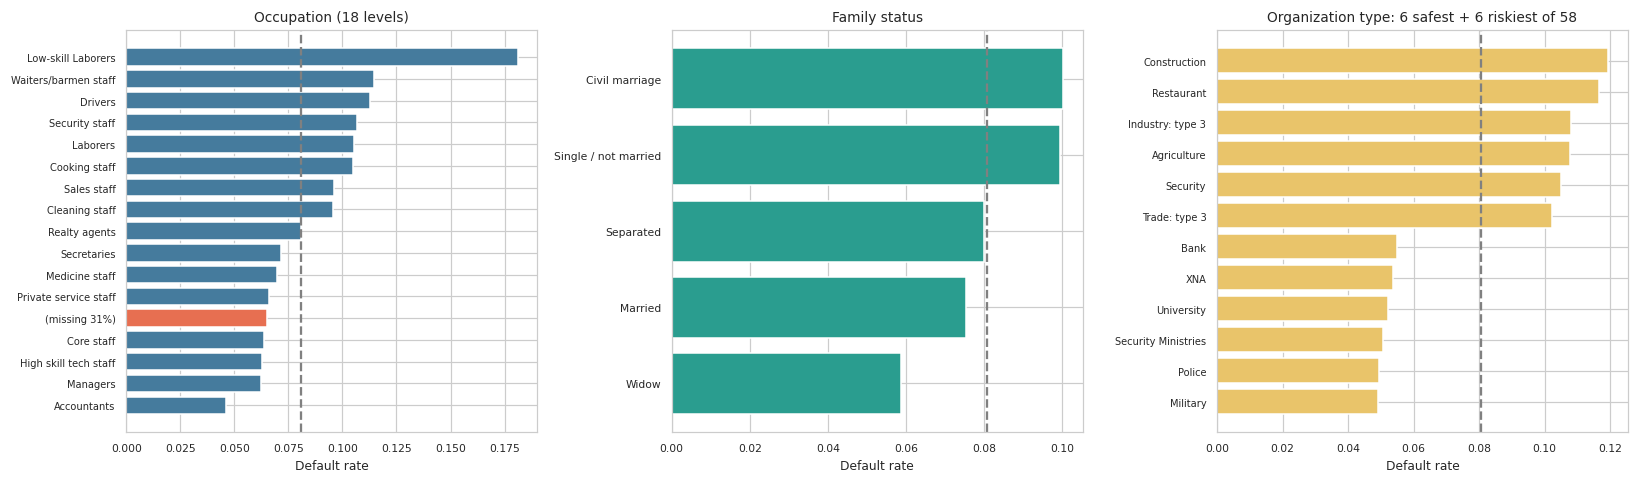

In [27]:
fig, takeaway = ep.plot_heavy_categoricals(dev)
print(takeaway)

## 24. The univariate AUC leakage screen — every feature, alone, vs the target

**What:** for each of the 104 numeric features, the AUC it achieves *by itself* (direction-corrected). The systematic version of "does anything look suspiciously predictive?"

**Why this is the most important addition of Part 2:**
1. **Leakage tripwire.** A single feature with AUC > 0.90 would mean target information snuck into the inputs (classic disaster: a column recorded *after* the outcome). Verdict: **PASS — nothing is close.** Top solo feature is `EXT_SOURCE_3` at 0.68.
2. **A free signal ranking for Phase 2.** The full table (`reports/tables/univariate_auc_scan.csv`) orders every feature by solo strength — a sanity baseline against model importances later.
3. **It quantifies the project's premise.** Only **9 of 104** features clear even 0.55 alone. The signal here is *diffuse* — no silver bullets — which is precisely why auxiliary-table aggregations (differentiator #1) and multivariate models are where the value is.

**A small discovery in the top-20:** building-block stats (`FLOORSMAX_*`) and `OWN_CAR_AGE` sneak in around 0.55–0.56 — weak alone, but evidence those oft-ignored housing columns aren't pure noise. Null-importance selection will adjudicate them properly.

PASS: no feature exceeds 0.90 alone (top: EXT_SOURCE_3 at 0.68). Only 9/104 clear 0.55 — signal is diffuse, which is exactly why aggregation features are differentiator #1.


,feature,auc_strength,direction,coverage,leakage_flag
0,EXT_SOURCE_3,0.6797,risk_down,0.802,False
1,EXT_SOURCE_1,0.6659,risk_down,0.437,False
2,EXT_SOURCE_2,0.6553,risk_down,0.998,False
3,DAYS_BIRTH,0.5843,risk_up,1.000,False
4,DAYS_EMPLOYED,0.5823,risk_up,0.821,False
5,OWN_CAR_AGE,0.5600,risk_up,0.340,False
6,DAYS_LAST_PHONE_CHANGE,0.5549,risk_up,1.000,False
7,DAYS_ID_PUBLISH,0.5537,risk_up,1.000,False
8,FLOORSMAX_AVG,0.5502,risk_down,0.503,False
9,FLOORSMAX_MEDI,0.5499,risk_down,0.503,False


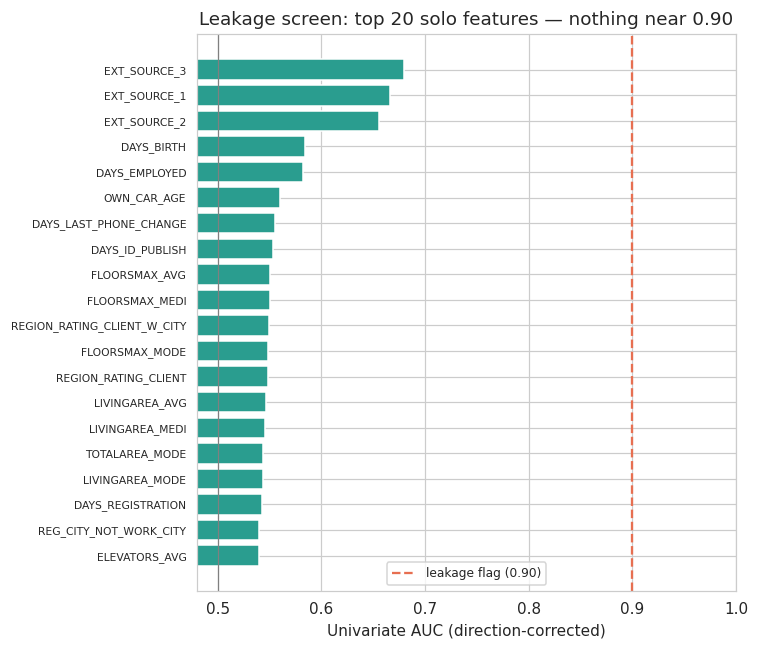

In [28]:
scan = univariate_auc_scan(dev)
fig, takeaway = ep.plot_univariate_auc(dev, scan)
print(takeaway)
scan.head(15)

## 25. Two things we checked and *cannot* have — written down so nobody wonders later

**1. There is no time axis.** The dataset has no application dates (anonymized to relative days). So an **out-of-time validation** — training on older applications, testing on newer ones, the way real banks validate credit models — is *impossible here*. Our random stratified holdout measures generalization to *similar* applicants, not robustness to *future* ones. This is a genuine limitation of the dataset, it goes verbatim into `docs/METHODOLOGY.md`, and it is exactly why Phase 6b's drift monitoring exists in the design.

**2. The label is one-sided by construction.** `TARGET = 1` means payment difficulties on early installments of *granted* loans. Rejected applicants have no label at all — we observe outcomes only for the accepted population (the **reject inference** problem, Phase 7 write-up). Both flat results above (leverage, DTI) are probably *symptoms* of this: the data was pre-filtered on exactly those variables.

---
# Part 3 — Final risk review: could anything here change a future *outcome*?

One last pass with a stricter filter: not "what else could we look at," but "what unexamined thing could change a downstream **decision or number**." Three items passed that filter. Two were checkable — both found something. One is uncheckable and gets documented.

## 26. The cost model's term formula is biased ~30% — not "slightly"

**What:** Phase 4 will compute each cash loan's term as `AMT_CREDIT / (12 × AMT_ANNUITY)` — a zero-interest approximation, because the application table gives no actual term. The spec predicted it "slightly understates" the true term. `previous_application` lets us *test* that: for 312,536 prior approved cash loans we know the **actual** number of payments (`CNT_PAYMENT`) *and* can compute the implied term on the same loans.

**The finding:** the formula understates the true term with a **median ratio of 0.707** — a ~30% understatement, not slight — and the bias **grows with term**: ~0.79 for loans ≤1y down to ~0.50 for 5–7y loans. (Why: the annuity includes interest, so credit ÷ annuity < number of payments; the longer the loan, the larger interest's share.)

**Why this matters for t*(x):** margin `m(x) = r_net × term/2` scales with term, so understating term understates margin, which **lowers every threshold** — the system rejects more marginal customers than the stated economics would justify. And because the bias is term-dependent, the *spread* of t*(x) across loan lengths is compressed.

**The decision (and why we do NOT "fix" it):**
1. **The formula stays.** Three reasons. First, `CNT_PAYMENT` exists only for *prior* loans — current applications simply don't carry an actual term, so the formula is the only option at scoring time regardless. Second, the term formula was **frozen in the spec before any results**; deriving a correction factor now, however well-intentioned, starts down the exact parameter-revision road pre-registration exists to block — and a single factor would mis-correct anyway (the bias is term-dependent). Third, the bias direction is **conservative** for a lender: understated margins mean stricter approvals, never looser.
2. **The magnitude goes in the docs.** "Conservative, median ~30%, term-dependent (0.79→0.50)" replaces the spec's one qualitative sentence in `METHODOLOGY.md`. A quantified known bias beats an adjective.
3. **Interpretation guardrail for Phase 4:** when the t*(x) histogram appears, its long-term tail is compressed by this bias — reported thresholds for long loans are *lower bounds* on the economically implied ones.

In [29]:
from src.data.load import load_previous_application
from src.data.supplementary import term_formula_validation, gender_product_mix

prev = load_previous_application()
tv = term_formula_validation(prev)
print(f"overall median implied/actual ratio: {tv.attrs['overall_median_ratio']:.3f}")
print(f"share of loans where formula understates term: {tv.attrs['share_understated']:.1%}")
tv

overall median implied/actual ratio: 0.707
share of loans where formula understates term: 92.2%


,median_ratio,p25,p75,n
term_actual,,,,
"(0.5, 1.0]",0.790,0.755,0.834,86118
"(1.0, 2.0]",0.707,0.643,0.746,98498
"(2.0, 3.0]",0.615,0.540,0.661,53741
"(3.0, 5.0]",0.535,0.470,0.594,49713
"(5.0, 7.0]",0.504,0.492,0.516,26


## 27. Gender × product mix — the t*(x) disparity gets a pre-registered direction

**What:** Phase 5b includes a novel check the instance-dependent rule creates: does the *distribution of thresholds* t*(x) differ across gender groups purely through product mix? We can measure the mix now.

**The finding:** small but nonzero differences — women hold slightly **more** revolving products (9.75% vs 9.10%) and slightly **longer** cash terms (median 1.73y vs 1.63y). Both differences push in the same direction: marginally **higher** (more lenient) thresholds for women via the cost model, before any model score is involved.

**Why write this down now:** it converts the Phase 5b policy-disparity check from "let's see what happens" into a **pre-registered directional expectation**: expect a small leniency tilt toward female applicants in t*(x), driven by term/product mix, *opposite in sign* to any disparity the model scores may introduce (male base default rates are higher). If Phase 5b finds exactly that, it was predicted here; if it finds something else, that's a genuine surprise worth investigating — either way, the reading was fixed before the result existed.

In [30]:
gender_product_mix(dev)

,share_revolving,cash_term_median,avg_credit,n
CODE_GENDER,,,,
F,0.0975,1.7323,593014.8215,161887
M,0.0910,1.6329,611512.3057,84119


## 28. The check we *cannot* run: repeated people

**What we'd want to verify:** that the same physical person never appears in both dev and holdout (identity leakage would let the model "memorize" a person across the boundary and inflate holdout metrics).

**Why we can't:** `SK_ID_CURR` identifies *applications*, and the dataset carries no person-level key, no names, no stable identifiers across applications. If one person filed twice, they'd be two unlinkable rows.

**Why the risk is bounded:** `previous_application` shows prior applications as *history attached to* a current application — not as separate labeled rows — so the main duplication channel is closed by the data's design. Residual risk (one person, two contemporaneous applications) is real but undetectable and almost certainly tiny.

**Disposition:** documented in `METHODOLOGY.md` as an unverifiable assumption of the random split — sitting right next to its sibling limitation, the impossibility of out-of-time validation (section 25).

---
# Executive summary

**Top findings (the ten that matter):**
1. 8.07% default rate — accuracy is meaningless; everything downstream runs on AUC, calibration, and cost.
2. External bureau scores dominate: 6× default spread, all three agree; `ext_source_mean` + count-present are priority features.
3. **Leakage screen: PASS** — no feature exceeds AUC 0.90 alone (max: 0.68); signal is diffuse (9/104 features >0.55 solo).
4. Missingness is signal, confirmed three independent ways (EXT_SOURCE_1, occupation, bureau coverage).
5. Prior refusal share at Home Credit = 2.2× monotone risk multiplier — strongest non-bureau-score signal found.
6. Down-payment ratio doubles risk (6.5% → 12.8%); 71% of cash loans finance fees into principal.
7. *No bureau history* = riskiest group (10.1%); *no prior HC apps* = safest (6.0%) — two "no history" flags with opposite meanings, kept separate.
8. Every affordability variable (income, credit, leverage, DTI) is individually weak — the reject-inference footprint.
9. Occupation spans 4.6%–18.1% default; organization type (58 levels) forces fold-safe target encoding.
10. Term drives the future t*(x) variation; terms cluster 1–3y with *non-monotonic* risk — and the term formula's ~30% conservative bias is now quantified (§26).
11. Gender product-mix differences pre-register a small leniency tilt toward women in t*(x) via term/product mix (§27) — direction fixed before Phase 5b runs.

**Major modeling risks:** the term formula understates true terms ~30% (term-dependent, conservative direction — frozen formula kept, magnitude documented, Phase 4 histogram read as lower bounds); fold-boundary leakage during Phase 2 encoding/imputation (mitigated by fold-safe rules + integrity re-check); the 41 sparse housing columns wasting selection budget (null-importance handles); income outlier distorting the scorecard (log transform).

**Data-quality issues:** pensioner sentinel (fixed in loader), 117M income outlier, 10 near-constant columns, 2 XNA genders, 10 missing `AMT_ANNUITY` rows feeding the cost model.

**Recommended preprocessing (all fold-safe, Phase 2):** sentinel → NaN + `is_pensioner`; `_is_missing` flags for EXT_SOURCE_1/occupation; log-income for logistic only; drop near-constants + currency; target-encode organization type inside folds.

**Expected strongest predictors:** EXT_SOURCE aggregate, prior-refusal share, bureau overdue/utilization aggregates, down-payment ratio, age/employment.
**Expected weakest:** raw income, raw credit amount, DTI, leverage (solo), document flags.

## Detailed hand-off table — what Phase 1 hands to Phase 2

| # | Finding | Consequence downstream |
|---|---|---|
| 1 | 8.07% default rate | never use accuracy; AUC + calibration + costs |
| 2 | EXT_SOURCE = 6× spread | will dominate importances — expected, not suspicious |
| 3 | EXT_SOURCE_1 56% missing, missingness predictive | `_is_missing` flags in Phase 2 |
| 4 | `DAYS_EMPLOYED` sentinel (17.9%) | NaN + `is_pensioner` flag |
| 5 | Revolving only 9.5% of book | contract-based LGD/EAD moves few applicants — expect a modest Phase 4 gap |
| 6 | Terms cluster 1–3y, non-monotonic risk | term drives t*(x); document the non-monotonicity |
| 7 | Leverage deciles flat | leverage needs interactions |
| 8 | Gender base rates differ (7.0% vs 10.1%) | fairness flag pre-registered; measure & disclose in 5b |
| 9 | Income outlier 248× p99; 10 dead columns | log-transform for logistic; drop near-constants |
| 10 | Education/income-type patterns strong & sensible | keep; they're also why the gender proxy check will fire |
| 11 | *No bureau history* = riskiest (10.1%) | `has_bureau_history` flag; quality > count aggregates |
| 12 | Prior refusal share = 2.2× monotone signal | top Phase 2 aggregation from previous_application |
| 13 | Two kinds of "no history" point opposite ways | separate flags per aux table, never one merged flag |
| 14 | bureau_balance: DPD statuses rare (~1.3%), coverage only 35.7% | ever-DPD flags + mandatory coverage flag |
| 15 | Currency 99.9% one value; 37% bureau loans active | drop currency; build active-loan aggregates |
| 16 | DTI nearly flat (reject-inference symptom) | keep for interactions; expect no solo lift |
| 17 | Down-payment ratio: 71% finance fees; risk 6.5%→12.8% | priority Phase 2 feature + `financed_fees_share` |
| 18 | No time axis in data | out-of-time validation impossible — documented limitation; monitoring covers the gap in spirit |

**Preprocessing status: still raw by design.** Every rule the data needs is now written down (audit table + this summary); all of it executes fold-safely in Phase 2.

**Checkpoint: PASSED.** 20 figures in `reports/figures/`, 9 tables in `reports/tables/`, expectations written down before modeling. Phase 2 (feature engineering) may begin.